In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [34]:
df=pd.read_csv("C:\\Users\\HP\\Downloads\\loan_data.csv")
# df.head

In [44]:
#cleaning data 
df = df[df['person_age'] <= 100]
print(df['person_age'].max())

94.0


In [45]:
from sklearn.metrics import roc_auc_score

# Target
y = df["loan_status"]

# Find numerical columns
numeric_columns = df.select_dtypes(include="number").columns

results = []
for column in numeric_columns:

    # Don't use the target itself
    if column == "loan_status":
        continue

    # Remove missing values
    temp = df[[column, "loan_status"]].dropna()

    X = temp[[column]]
    y_temp = temp["loan_status"]

    # Skip columns with only one unique value
    if X[column].nunique() < 2:
        continue

    # Train logistic regression
    model = LogisticRegression(max_iter=1000)
    model.fit(X, y_temp)

    # Probability prediction
    probability = model.predict_proba(X)[:, 1]

    # AUC
    auc = roc_auc_score(y_temp, probability)

    results.append([column, auc])

# Results
results_df = pd.DataFrame(
    results,
    columns=["Column", "AUC"]
).sort_values("AUC", ascending=False)

print(results_df)

                       Column       AUC
5         loan_percent_income  0.724979
4               loan_int_rate  0.716228
1               person_income  0.690876
3                   loan_amnt  0.560190
0                  person_age  0.520930
2              person_emp_exp  0.518756
6  cb_person_cred_hist_length  0.514092
7                credit_score  0.505757


In [42]:
# Select X and y
X = df[["loan_percent_income"]]
y = df["loan_status"]

# Remove missing values
data = pd.concat([X, y], axis=1).dropna()

X = data[["loan_percent_income"]]
y = data["loan_status"]

#  Create Logistic Regression model
model = LogisticRegression()

#  Train the model
model.fit(X, y)

#  Get model parameters
print("Intercept:", model.intercept_[0])
print("Coefficient:", model.coef_[0][0])

# Make predictions
predictions = model.predict(X)

print("\nFirst 10 predictions:")
print(predictions[:10])

#  Predict probability
probability = model.predict_proba(X)

print("\nFirst 10 probabilities:")
print(probability[:10])

Intercept: -2.8598249894350696
Coefficient: 10.211728197984304

First 10 predictions:
[1 0 1 1 1 0 1 1 1 0]

First 10 probabilities:
[[0.10490057 0.89509943]
 [0.88522689 0.11477311]
 [0.16337395 0.83662605]
 [0.16337395 0.83662605]
 [0.07226602 0.92773398]
 [0.71495991 0.28504009]
 [0.28526068 0.71473932]
 [0.28526068 0.71473932]
 [0.32865383 0.67134617]
 [0.82234263 0.17765737]]


Loan Status:
loan_status
0    35000
1    10000
Name: count, dtype: int64


D:\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(



loan_percent_income
Intercept: -2.847603900619124
Coefficient: 10.153398856401015
Train Accuracy: 0.8084166666666667
Test Accuracy: 0.8106666666666666
Decision Boundary: 0.2804581934475968

loan_int_rate
Intercept: -4.685216263670838
Coefficient: 0.29416997224342245
Train Accuracy: 0.7946388888888889
Test Accuracy: 0.7925555555555556
Decision Boundary: 15.926901811017856


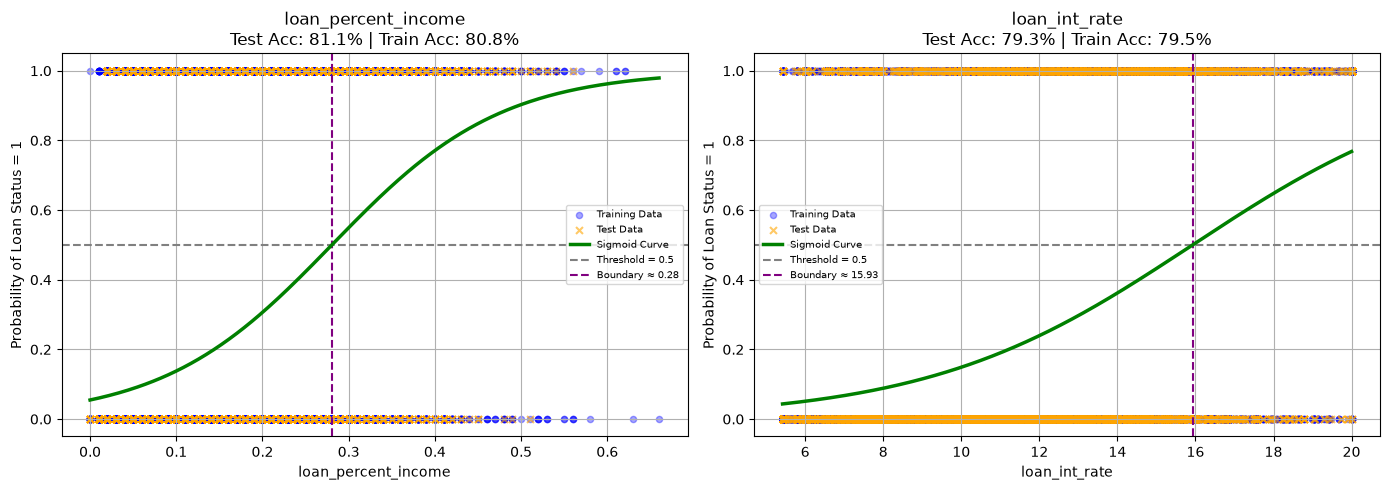

In [36]:
# 1. LOAD DATASET
data = pd.read_csv("C:\\Users\\HP\\Downloads\\loan_data.csv")

# 2. CHECK TARGET
print("Loan Status:")
print(data["loan_status"].value_counts())

# 3. FEATURES TO COMPARE
features_to_compare = ["loan_percent_income","loan_int_rate",]


def plot_logistic_for_feature(feature_name, ax):

    # Select X and y
    X = data[[feature_name]]
    y = data["loan_status"]

    # Remove missing values
    temp_data = pd.concat([X, y],axis=1).dropna()

    X = temp_data[[feature_name]]
    y = temp_data["loan_status"]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

    # Create model
    model = LogisticRegression()

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Accuracy
    train_accuracy = accuracy_score(y_train,y_train_pred)
    test_accuracy = accuracy_score(y_test,y_test_pred)

    # Model parameters

    intercept = model.intercept_[0]
    coefficient = model.coef_[0][0]

    # Create smooth X values
    x_range = np.linspace(X[feature_name].min(),X[feature_name].max(),300).reshape(-1, 1)

    # Calculate probabilities
    y_probability = model.predict_proba(x_range)[:, 1]
    
    # Decision boundary
    decision_boundary = (-intercept / coefficient)


    # ========================================================
    # 5. PLOT ACTUAL DATA
    # ========================================================

    # Training data
    ax.scatter(X_train[feature_name],y_train,color="blue",alpha=0.35,s=20,label="Training Data")

    # Test data
    ax.scatter(X_test[feature_name],y_test,color="orange",marker="x",alpha=0.6,s=25,label="Test Data")

    # 6. SIGMOID CURVE
    ax.plot(x_range,y_probability,color="green",linewidth=2.5,label="Sigmoid Curve",zorder=5)

    # 7. 50% THRESHOLD
    ax.axhline(0.5,linestyle="--",color="gray",label="Threshold = 0.5")

    # 8. DECISION BOUNDARY
    ax.axvline(decision_boundary,color="purple",linestyle="--",label=f"Boundary ≈ {decision_boundary:.2f}")


    # 9. LABELS
    ax.set_xlabel(feature_name)
    ax.set_ylabel("Probability of Loan Status = 1")

    ax.set_title(
        f"{feature_name}\n"
        f"Test Acc: {test_accuracy*100:.1f}% | "
        f"Train Acc: {train_accuracy*100:.1f}%"
    )
    ax.legend(fontsize=7)
    ax.grid(True)

    # 10. PRINT RESULTS

    print("\n======================================")
    print(feature_name)
    print("======================================")

    print("Intercept:", intercept)
    print("Coefficient:", coefficient)
    print("Train Accuracy:",train_accuracy)
    print("Test Accuracy:",test_accuracy)
    print("Decision Boundary:",decision_boundary)


# 11. CREATE GRID
n_features = len(features_to_compare)
n_cols = 2
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows,n_cols,figsize=(14, 5 * n_rows))
axes = axes.flatten()

# 12. RUN FOR EACH FEATURE
for i, feature in enumerate(features_to_compare):
    plot_logistic_for_feature(feature,axes[i])

# 13. REMOVE UNUSED PLOTS
for j in range(i + 1,len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()